## Setup

In [1]:
!nvidia-smi

Thu Dec  4 08:22:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-16GB           On  |   00000000:3B:00.0 Off |                    0 |
| N/A   44C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pace-quota


Gathering storage and job accounting information for user: wchia7

  ** Please note that the information and display format of this tool **
  ** is subject to change and should *not* be used for scripting.    **


                                          Welcome to the ICE Cluster!                                           
 * Your Name (as PACE knows it)          :   Wen Han Chia                  
 * UserID                                :   3370265                       
 * Username                              :   wchia7                        
 * Your Email (for PACE contact)         :                                 

                                                  ICE Storage                                                   
Filesystem                                             Usage (GB)    Limit
Home:/home/hice1/wchia7                                      13.7     30.0  45.6%   
Scratch:/storage/ice1/6/5/wchia7                            224.0    300.0  74.7%   


Install YOLO package

In [3]:
!pip install ultralytics

In [1]:
from ultralytics import YOLO 
import os
from IPython.display import display, Image 
from IPython import display 
display.clear_output()

In [2]:
import ultralytics
print(ultralytics.__version__)

8.3.223


In [3]:
from pipeline_evaluation import evaluate_performance

## Evaluate Model's Performance

## Settings: 

conf_thresh: 0.5 
nms_iou_thresh :0.25
topk: 5

### Evaluate for mAP

In [7]:
evaluate_performance(yolo_model_file_path="./runs/detect/train23_yolov8x_dataset_v4_pipeline/weights/best.pt",
    swin_model_file_path=None, det_conf_thresh=0.001, nms_iou_thresh=0.7, eval_iou_thresh = 0.5, top_k=5)

--- EVALUATION PIPELINE ---
YOLO Model Config: NMS_IOU_THRESHOLD: 0.7 
 CONF_THRESH: 0.001 
 MAX_DETECTION: 5 

EVAL Config: EVAL_IOU_THRESHOLD: 0.5 

--- LOADING MODELS ---
YOLO_MODEL_FILE_PATH: ./runs/detect/train23_yolov8x_dataset_v4_pipeline/weights/best.pt 

--- COMPLETED LOADING MODELS ---
--- Saving results and debug images to inference/run_20251205_110146 ---




 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/116461_9891309.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/116461_9891309.txt

Label File content (GT): [1.0, 0.25234375, 0.42734375, 0.50390625, 0.25]
GT Box (yolo to xyxy): [0, 194, 323, 354]

--- Pipeline inference ---

0: 640x640 2 brown_anoles, 3 green_anoles, 23.1ms
Speed: 36.4ms preprocess, 23.1ms inference, 285.2ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[5.1843e-01, 1.9740e+02, 3.2320e+02, 3.5387e+02, 7.0344e-01, 1.0000e

0: 640x640 2 knight_anoles, 22.9ms
Speed: 1.4ms preprocess, 22.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[1.1723e+02, 4.0863e-02, 5.4571e+02, 4.5196e+02, 7.4745e-01, 4.0000e+00],
        [1.3811e+02, 1.0786e+02, 5.3680e+02, 6.3860e+02, 3.7702e-01, 4.0000e+00]], device='cuda:0')
Individual Detection result: [117.2266845703125, 0.040863037109375, 545.714111328125, 451.9601135253906, 0.7474488615989685, 4.0]
Prediction bbox: 117 0 546 452, Conf: 0.747, Pred_label: knight
Individual Detection result: [138.10711669921875, 107.860595703125, 536.8012084960938, 638.6018676757812, 0.377017617225647, 4.0]
Prediction bbox: 138 108 537 639, Conf: 0.377, Pred_label: knight
Annotated image saved to: inference/run_20251205_110146/annotated_images/36391_96732137_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: knight -> GT: knight IOU: 0.8670381593138514
No best match found for Pred: kni


Label File content (GT): [4.0, 0.501623, 0.55113, 0.387246, 0.897739]
GT Box (yolo to xyxy): [116, 51, 261, 499]

--- Pipeline inference ---

0: 640x480 1 green_anole, 3 knight_anoles, 49.7ms
Speed: 45.6ms preprocess, 49.7ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Raw Detection result: tensor([[1.2300e+02, 5.4087e+01, 2.8219e+02, 5.0000e+02, 7.9192e-01, 4.0000e+00],
        [2.7242e+01, 3.4324e+01, 2.8103e+02, 5.0000e+02, 1.7818e-02, 4.0000e+00],
        [3.1154e+01, 1.7045e+01, 2.6870e+02, 3.8210e+02, 1.3352e-03, 4.0000e+00],
        [3.3449e+01, 5.7873e+00, 1.6574e+02, 2.3158e+02, 1.0227e-03, 3.0000e+00]], device='cuda:0')
Individual Detection result: [123.00468444824219, 54.08658981323242, 282.1915283203125, 500.0, 0.7919201850891113, 4.0]
Prediction bbox: 123 54 282 499, Conf: 0.792, Pred_label: knight
Individual Detection result: [27.24151611328125, 34.32350158691406, 281.03436279296875, 500.0, 0.017818037420511246, 4.0]
Prediction bbox: 27 34 281 499, Co

0: 640x640 1 knight_anole, 23.0ms
Speed: 1.4ms preprocess, 23.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[2.4622e-01, 2.0123e+02, 4.4187e+02, 6.3995e+02, 9.5607e-01, 4.0000e+00]], device='cuda:0')
Individual Detection result: [0.2462158203125, 201.23345947265625, 441.865478515625, 639.9482421875, 0.9560718536376953, 4.0]
Prediction bbox: 0 201 442 639, Conf: 0.956, Pred_label: knight
Annotated image saved to: inference/run_20251205_110146/annotated_images/36391_94470018_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: knight -> GT: knight IOU: 0.9954441913439636



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36514_613168.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36514_613168.txt

Label File content (GT): [3.0, 0.490625, 0.5359375, 0.55234375, 0.92421875]
GT Box 

0: 640x640 1 crested_anole, 22.9ms
Speed: 1.4ms preprocess, 22.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[192.3973, 102.2598, 397.9327, 625.1961,   0.9379,   2.0000]], device='cuda:0')
Individual Detection result: [192.39730834960938, 102.25982666015625, 397.9327087402344, 625.1961059570312, 0.9378933310508728, 2.0]
Prediction bbox: 192 102 398 625, Conf: 0.938, Pred_label: crested
Annotated image saved to: inference/run_20251205_110146/annotated_images/36488_76820250_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: crested -> GT: crested IOU: 0.975197190608395



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36488_9938238.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36488_9938238.txt

Label File content (GT): [2.0, 0.385232, 0.181013, 0.455696, 0.210127]
GT Box (yo

...


Label File content (GT): [3.0, 0.5625, 0.3359375, 0.49765625, 0.67109375]
GT Box (yolo to xyxy): [201, 0, 519, 430]

--- Pipeline inference ---

0: 640x640 2 green_anoles, 21.0ms
Speed: 1.4ms preprocess, 21.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[1.9337e+02, 0.0000e+00, 5.1870e+02, 4.3584e+02, 9.2183e-01, 3.0000e+00],
        [2.4507e+02, 1.8712e+02, 5.1908e+02, 4.3495e+02, 2.9721e-03, 3.0000e+00]], device='cuda:0')
Individual Detection result: [193.37237548828125, 0.0, 518.701171875, 435.8436279296875, 0.9218325614929199, 3.0]
Prediction bbox: 193 0 519 436, Conf: 0.922, Pred_label: green
Individual Detection result: [245.0682373046875, 187.12091064453125, 519.082763671875, 434.95318603515625, 0.0029721457976847887, 3.0]
Prediction bbox: 245 187 519 435, Conf: 0.003, Pred_label: green
Annotated image saved to: inference/run_20251205_110146/annotated_images/36514_640834_annotated.jpg

--- Matching each prediction to best grou


Label File content (GT): [3.0, 0.45078125, 0.48984375, 0.325, 0.5640625]
GT Box (yolo to xyxy): [184, 133, 392, 494]

--- Pipeline inference ---

0: 640x640 5 green_anoles, 20.9ms
Speed: 1.4ms preprocess, 20.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[1.8944e+02, 1.3476e+02, 4.4829e+02, 4.9066e+02, 8.3229e-01, 3.0000e+00],
        [2.5002e+02, 1.3427e+02, 4.2881e+02, 3.4424e+02, 1.2649e-02, 3.0000e+00],
        [2.8411e+02, 1.3447e+02, 4.3168e+02, 3.1847e+02, 5.5036e-03, 3.0000e+00],
        [3.0755e+02, 1.3427e+02, 4.7077e+02, 3.1483e+02, 3.5253e-03, 3.0000e+00],
        [2.6818e+02, 1.3471e+02, 4.0657e+02, 2.9211e+02, 1.3487e-03, 3.0000e+00]], device='cuda:0')
Individual Detection result: [189.44480895996094, 134.76483154296875, 448.2899169921875, 490.66192626953125, 0.8322864770889282, 3.0]
Prediction bbox: 189 135 448 491, Conf: 0.832, Pred_label: green
Individual Detection result: [250.0173797607422, 134.27276611328125, 428.


Label File content (GT): [0.0, 0.37265625, 0.47578125, 0.11640625, 0.4703125]
GT Box (yolo to xyxy): [201, 154, 276, 455]

--- Pipeline inference ---

0: 640x640 1 bark_anole, 2 crested_anoles, 2 green_anoles, 21.0ms
Speed: 1.5ms preprocess, 21.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[4.9307e+02, 3.4811e+02, 5.6238e+02, 6.1037e+02, 2.5692e-01, 0.0000e+00],
        [2.0430e+02, 1.4858e+02, 3.0189e+02, 5.2520e+02, 2.2183e-01, 2.0000e+00],
        [2.0334e+02, 1.6509e+02, 2.8078e+02, 4.9854e+02, 1.2200e-02, 2.0000e+00],
        [4.9086e+02, 3.4720e+02, 6.1715e+02, 6.1123e+02, 6.2717e-03, 3.0000e+00],
        [2.0496e+02, 1.4604e+02, 4.0117e+02, 5.6398e+02, 4.8463e-03, 3.0000e+00]], device='cuda:0')
Individual Detection result: [493.06573486328125, 348.1092529296875, 562.3831176757812, 610.3743896484375, 0.2569151818752289, 0.0]
Prediction bbox: 493 348 562 610, Conf: 0.257, Pred_label: bark
Individual Detection result: [204.29873


Label File content (GT): [1.0, 0.6171875, 0.315625, 0.62109375, 0.1796875]
GT Box (yolo to xyxy): [196, 144, 594, 260]

--- Pipeline inference ---

0: 640x640 1 brown_anole, 4 green_anoles, 21.0ms
Speed: 1.4ms preprocess, 21.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[1.9781e+02, 1.4330e+02, 5.9405e+02, 2.5817e+02, 9.1177e-01, 1.0000e+00],
        [5.4808e+01, 6.1964e+02, 1.7656e+02, 6.3990e+02, 1.7650e-02, 3.0000e+00],
        [5.4225e+01, 6.1902e+02, 1.2465e+02, 6.3997e+02, 1.4369e-02, 3.0000e+00],
        [0.0000e+00, 6.1819e+02, 1.1220e+02, 6.3963e+02, 3.2854e-03, 3.0000e+00],
        [5.4088e+01, 6.1990e+02, 2.5731e+02, 6.3992e+02, 2.8376e-03, 3.0000e+00]], device='cuda:0')
Individual Detection result: [197.8054962158203, 143.29522705078125, 594.0493774414062, 258.1693420410156, 0.9117697477340698, 1.0]
Prediction bbox: 198 143 594 258, Conf: 0.912, Pred_label: brown
Individual Detection result: [54.80848693847656, 619.64025

Saved Precision-Recall curves to: inference/run_20251205_110146/pr_curves_iou_50.png


### Evaluate for Confusion Matrix

In [8]:
evaluate_performance(yolo_model_file_path="./runs/detect/train23_yolov8x_dataset_v4_pipeline/weights/best.pt",
    swin_model_file_path=None, det_conf_thresh=0.3, nms_iou_thresh=0.7, eval_iou_thresh = 0.5, top_k=5)

--- EVALUATION PIPELINE ---
YOLO Model Config: NMS_IOU_THRESHOLD: 0.7 
 CONF_THRESH: 0.3 
 MAX_DETECTION: 5 

EVAL Config: EVAL_IOU_THRESHOLD: 0.5 

--- LOADING MODELS ---
YOLO_MODEL_FILE_PATH: ./runs/detect/train23_yolov8x_dataset_v4_pipeline/weights/best.pt 

--- COMPLETED LOADING MODELS ---
--- Saving results and debug images to inference/run_20251205_110318 ---




 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/116461_9891309.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/116461_9891309.txt

Label File content (GT): [1.0, 0.25234375, 0.42734375, 0.50390625, 0.25]
GT Box (yolo to xyxy): [0, 194, 323, 354]

--- Pipeline inference ---

0: 640x640 1 brown_anole, 20.9ms
Speed: 1.6ms preprocess, 20.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[  0.5184, 197.3991, 323.2000, 353.8662,   0.7034,   1.0000]], device='cuda:0')
Individual

0: 640x640 1 brown_anole, 20.9ms
Speed: 1.3ms preprocess, 20.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[165.4919, 308.6002, 360.1602, 347.1842,   0.8562,   1.0000]], device='cuda:0')
Individual Detection result: [165.49185180664062, 308.6001892089844, 360.1602478027344, 347.1841735839844, 0.8561618328094482, 1.0]
Prediction bbox: 165 309 360 347, Conf: 0.856, Pred_label: brown
Annotated image saved to: inference/run_20251205_110318/annotated_images/116461_9891671_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: brown -> GT: brown IOU: 0.838391502276176



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36391_92824180.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36391_92824180.txt

Label File content (GT): [4.0, 0.58515625, 0.475, 0.12265625, 0.246875]
GT Box (yolo to 

0: 640x640 2 knight_anoles, 21.0ms
Speed: 1.3ms preprocess, 21.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[280.1425,  76.8914, 608.2456, 542.8361,   0.9060,   4.0000],
        [  0.0000,  77.8572, 615.0762, 554.0587,   0.7625,   4.0000]], device='cuda:0')
Individual Detection result: [280.1424560546875, 76.89141845703125, 608.24560546875, 542.8360595703125, 0.905994713306427, 4.0]
Prediction bbox: 280 77 608 543, Conf: 0.906, Pred_label: knight
Individual Detection result: [0.0, 77.85716247558594, 615.076171875, 554.0587158203125, 0.7625402212142944, 4.0]
Prediction bbox: 0 78 615 554, Conf: 0.763, Pred_label: knight
Annotated image saved to: inference/run_20251205_110318/annotated_images/36391_81505029_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
No best match found for Pred: knight

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: knight -> GT: knigh

Annotated image saved to: inference/run_20251205_110318/annotated_images/36514_850152_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: green -> GT: green IOU: 0.7392038777908343



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36488_75082114.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36488_75082114.txt

Label File content (GT): [2.0, 0.5375, 0.47109375, 0.64296875, 0.59765625]
GT Box (yolo to xyxy): [138, 110, 550, 493]

--- Pipeline inference ---

0: 640x640 1 bark_anole, 20.9ms
Speed: 1.3ms preprocess, 20.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[139.1640, 109.2773, 551.6356, 495.6949,   0.7286,   0.0000]], device='cuda:0')
Individual Detection result: [139.16400146484375, 109.27726745605469, 551.6356201171875, 495.69488525390625, 0.7286460995674133, 0.0]
Predi

0: 640x640 1 brown_anole, 20.9ms
Speed: 1.4ms preprocess, 20.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[246.5811, 226.3162, 446.4644, 310.6660,   0.9376,   1.0000]], device='cuda:0')
Individual Detection result: [246.58114624023438, 226.31622314453125, 446.4643859863281, 310.666015625, 0.9376407861709595, 1.0]
Prediction bbox: 247 226 446 311, Conf: 0.938, Pred_label: brown
Annotated image saved to: inference/run_20251205_110318/annotated_images/116461_9881959_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: brown -> GT: brown IOU: 0.8903378112528807



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36514_754144.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36514_754144.txt

Label File content (GT): [3.0, 0.4765625, 0.7109375, 0.246875, 0.57734375]
GT Box (yolo to xyx

...


Label File content (GT): [1.0, 0.56484375, 0.528125, 0.2125, 0.2484375]
GT Box (yolo to xyxy): [294, 258, 430, 418]

--- Pipeline inference ---

0: 640x640 1 brown_anole, 21.0ms
Speed: 1.3ms preprocess, 21.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[284.9835, 258.6422, 446.4767, 420.5310,   0.8654,   1.0000]], device='cuda:0')
Individual Detection result: [284.98345947265625, 258.6422119140625, 446.4766845703125, 420.531005859375, 0.8653711676597595, 1.0]
Prediction bbox: 285 259 446 421, Conf: 0.865, Pred_label: brown
Annotated image saved to: inference/run_20251205_110318/annotated_images/116461_9925794_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: brown -> GT: brown IOU: 0.8247768708520864



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36488_82622884.jpg 
Loaded label file: ../Dataset/yolo_training/fl

0: 640x640 1 green_anole, 21.6ms
Speed: 1.5ms preprocess, 21.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[ 29.9161,  21.5577, 576.1756, 526.4744,   0.8805,   3.0000]], device='cuda:0')
Individual Detection result: [29.91607666015625, 21.557662963867188, 576.1755981445312, 526.4744262695312, 0.8804565668106079, 3.0]
Prediction bbox: 30 22 576 526, Conf: 0.880, Pred_label: green
Annotated image saved to: inference/run_20251205_110318/annotated_images/36514_515271_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: green -> GT: green IOU: 0.9373900362404275



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36514_503500.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36514_503500.txt

Label File content (GT): [3.0, 0.41015625, 0.49375, 0.18828125, 0.14453125]
GT Box (yolo to xyx

Speed: 1.5ms preprocess, 21.6ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([], device='cuda:0', size=(0, 6))
Annotated image saved to: inference/run_20251205_110318/annotated_images/116461_9809746_annotated.jpg
Annotated image saved to: inference/run_20251205_110318/missed_detections/116461_9809746_annotated.jpg



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36488_95815641.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36488_95815641.txt

Label File content (GT): [2.0, 0.4921875, 0.5125, 0.6921875, 0.41328125]
GT Box (yolo to xyxy): [94, 196, 536, 460]

--- Pipeline inference ---

0: 640x640 1 crested_anole, 21.0ms
Speed: 1.4ms preprocess, 21.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[ 90.4065, 196.5195, 536.6296, 477.8913,   0.8611,   2.0000]], device='cuda:0')
Individual 

Raw Detection result: tensor([[ 25.8544, 155.9105, 542.0513, 495.1007,   0.9266,   3.0000]], device='cuda:0')
Individual Detection result: [25.85443115234375, 155.91046142578125, 542.0513305664062, 495.1007080078125, 0.926593542098999, 3.0]
Prediction bbox: 26 156 542 495, Conf: 0.927, Pred_label: green
Annotated image saved to: inference/run_20251205_110318/annotated_images/36514_857702_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: green -> GT: green IOU: 0.9824552377032311



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36455_71716067.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36455_71716067.txt

Label File content (GT): [0.0, 0.38626, 0.45047904191616767, 0.7662, 0.7213173652694611]
GT Box (yolo to xyxy): [2, 30, 385, 271]

--- Pipeline inference ---

0: 448x640 1 crested_anole, 18.7ms
Speed: 1.8ms preprocess, 18

0: 640x640 1 brown_anole, 21.0ms
Speed: 1.4ms preprocess, 21.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Raw Detection result: tensor([[172.1682, 303.1855, 450.8130, 422.0421,   0.8272,   1.0000]], device='cuda:0')
Individual Detection result: [172.16824340820312, 303.18548583984375, 450.8130187988281, 422.04205322265625, 0.8272454738616943, 1.0]
Prediction bbox: 172 303 451 422, Conf: 0.827, Pred_label: brown
Annotated image saved to: inference/run_20251205_110318/annotated_images/116461_9937794_annotated.jpg

--- Matching each prediction to best ground truth bbox by IoU ---
Best match found for Pred: brown -> GT: brown IOU: 0.9149447381066795



 --- Analyzing Image --- 
Loaded image file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/images/36488_77845172.jpg 
Loaded label file: ../Dataset/yolo_training/florida_five_anole_10000_v4/test/labels/36488_77845172.txt

Label File content (GT): [2.0, 0.59296875, 0.575, 0.79765625, 0.328125]
GT Box (yolo 

### Plot

In [9]:
from sklearn.metrics import accuracy_score
import os
import pandas as pd

RESULTS_PATH = "./inference/run_20251205_110318_yolov8x_class_eval/eval_results.csv"

if os.path.exists(RESULTS_PATH):
    df = pd.read_csv(RESULTS_PATH)
    y_true_all = df["y_true"].tolist()
    y_pred_all = df["y_pred"].tolist()

    # Compute top-1 accuracy
    top1_acc = accuracy_score(y_true_all, y_pred_all)
    print(f"Top-1 Accuracy: {top1_acc:.4f}")

    print(f"Loaded evaluation results from {RESULTS_PATH}")
else:
    print(f"Cannot find results path {RESULTS_PATH}")



Top-1 Accuracy: 0.7385
Loaded evaluation results from ./inference/run_20251205_110318_yolov8x_class_eval/eval_results.csv


### Visualize confusion matrix

Loaded evaluation results from ./inference/run_20251205_110318_yolov8x_class_eval/eval_results.csv


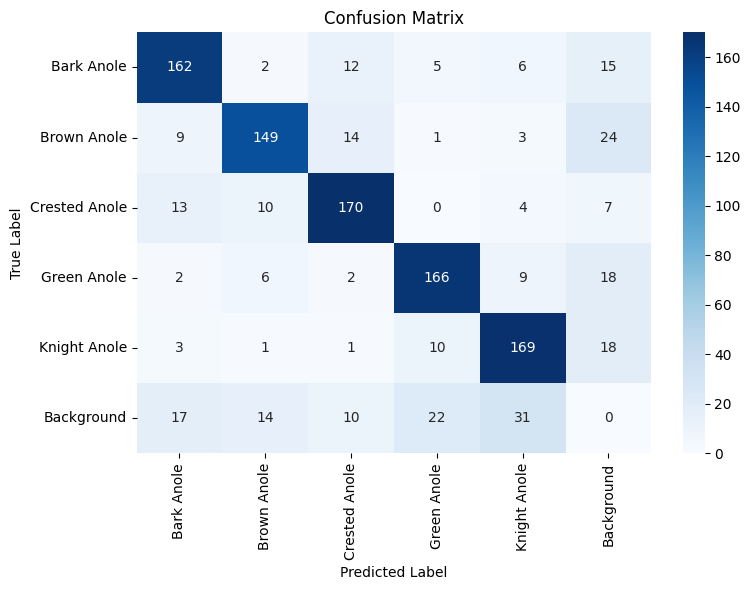

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import os

NUM_CLASSES = 5
MISSED_CLASS_ID = 5
ALL_CLASSES = list(range(NUM_CLASSES)) + [MISSED_CLASS_ID]
CLASS_NAMES = ["Bark Anole", "Brown Anole", "Crested Anole", "Green Anole", "Knight Anole"] + ["Background"]

RESULTS_PATH = "./inference/run_20251205_110318_yolov8x_class_eval/eval_results.csv"

if os.path.exists(RESULTS_PATH):
    df = pd.read_csv(RESULTS_PATH)
    y_true_all = df["y_true"].tolist()
    y_pred_all = df["y_pred"].tolist()
    print(f"Loaded evaluation results from {RESULTS_PATH}")
else:
    print("Cannot find results path")


cm = confusion_matrix(y_true_all, y_pred_all, labels=ALL_CLASSES)

# Plot heatmap
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


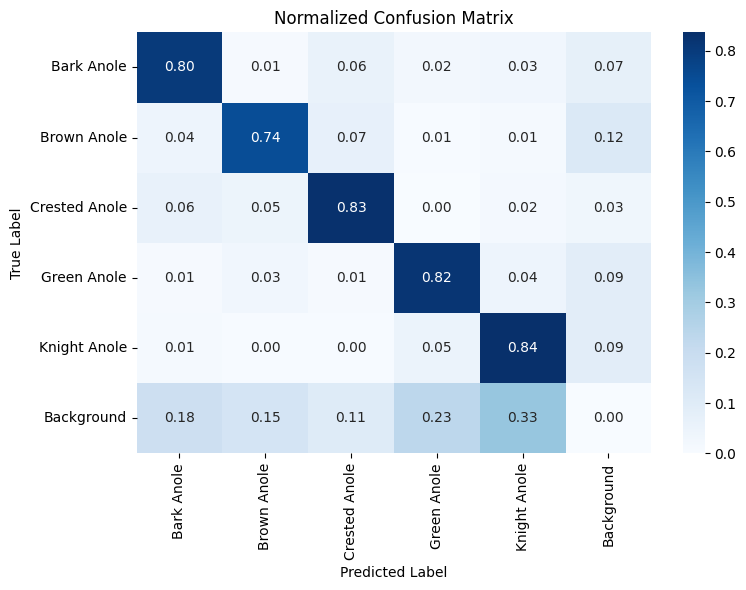

In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all, labels=ALL_CLASSES)

# Normalize by rows (true labels)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)  # Avoid NaNs

# Plot heatmap
cm_df = pd.DataFrame(cm_normalized, index=CLASS_NAMES, columns=CLASS_NAMES)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()